In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
from scipy.signal.windows import tukey, gaussian
from pathlib import Path
from scipy.signal import welch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [3]:



# =============================================================================
# FUNZIONI DI ANALISI AUDIO (da lab3.ipynb)
# =============================================================================

def power_spectrum(signal, rate):
    """
    Calcola lo spettro di potenza con finestra gaussiana.
    
    Mono: se il segnale è stereo, converte in mono
    Taglio sustain: elimina transitori iniziale/finale (10%-90%)
    Finestra gaussiana: riduce discontinuità ai bordi
    FFT: calcola la trasformata di Fourier
    """
    # 1. Gestione canali
    if np.ndim(signal) > 1:
        signal = signal[:, 0]

    # 2. Taglio dei bordi (10%-90%)
    n = len(signal)
    inizio, fine = int(n * 0.1), int(n * 0.9)
    signal = signal[inizio:fine]
    
    # 3. Finestra gaussiana
    M = len(signal)
    std_dev = M / 8 
    window = gaussian(M, std=std_dev)
    signal = signal * window
    
    # 4. FFT
    n_fft = 65536
    psd = np.abs(np.fft.rfft(signal, n=n_fft))**2
    freqs = np.fft.rfftfreq(n_fft, d=1/rate)

    return freqs, psd


def calcola_fondamentale(signal, sr, fmin=50, fmax=2000):
    """
    Trova la frequenza fondamentale (F0) con algoritmo di voto.
    
    1. FFT ad alta risoluzione (131072 campioni)
    2. Estrae i picchi con energia > 20% del massimo
    3. Genera candidati F0 dalle differenze tra picchi
    4. Voto di maggioranza: sceglie il candidato che spiega più armoniche
    """
    signal = signal - np.mean(signal)
    n_fft = 131072
    mag_spec = np.abs(np.fft.rfft(signal * np.blackman(len(signal)), n=n_fft))
    freqs = np.fft.rfftfreq(n_fft, d=1/sr)

    # 1. Estrazione dei picchi dominanti
    threshold = np.max(mag_spec) * 0.2
    peaks = []
    for i in range(2, len(mag_spec) - 1):
        if mag_spec[i] > threshold and mag_spec[i] > mag_spec[i-1] and mag_spec[i] > mag_spec[i+1]:
            if freqs[i] > fmin:
                peaks.append(freqs[i])
    
    if not peaks: return 0.0
    peaks = sorted(peaks)[:6]  # Prime 6 armoniche potenziali

    # 2. Generazione candidati F0
    candidati = []
    for i in range(len(peaks)):
        for j in range(i + 1, len(peaks)):
            # Distanza tra picchi
            diff = peaks[j] - peaks[i]
            if fmin <= diff <= fmax:
                candidati.append(diff)
            
            # MCD con tolleranza
            a, b = peaks[i], peaks[j]
            while b > 2.0:
                a, b = b, a % b
            if fmin <= a <= fmax:
                candidati.append(a)

    if not candidati: return peaks[0]

    # 3. Voto di maggioranza
    best_f0 = 0
    max_score = -1
    
    for c in candidati:
        score = 0
        for p in peaks:
            resto = p % c
            if resto < c * 0.03 or resto > c * 0.97:
                score += 1
        
        # Bonus: energia vicina al candidato
        idx_c = int(c / (sr / n_fft))
        score += (mag_spec[idx_c] / np.max(mag_spec))

        if score > max_score:
            max_score = score
            best_f0 = c

    return best_f0


def estrai_timbro(freqs, psd, f0, n_armoniche=5):
    """
    Estrae il vettore di timbro (prime N armoniche normalizzate).
    """
    if f0 <= 0:
        return np.zeros(n_armoniche)
        
    ampiezze = []
    for n in range(1, n_armoniche + 1):
        f_target = n * f0
        idx = np.abs(freqs - f_target).argmin()
        ampiezze.append(np.sqrt(psd[idx]))
    
    # Normalizzazione rispetto al picco massimo
    vettore_timbro = np.array(ampiezze) / (np.max(ampiezze) + 1e-9)
    return vettore_timbro


def freq_to_note(f, offset_cents=0):
    """
    Converte frequenza in nome nota MIDI.
    """
    if f <= 0: return "N/A"
    
    n = 12 * np.log2(f / 440.0) + 69 - (offset_cents / 100.0)
    n_rounded = int(round(n))
    
    notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    return f"{notes[n_rounded % 12]}{n_rounded // 12 - 1}"

In [4]:
def window_organ_signal(
    signal,
    sample_rate,
    return_info=False,
    search_step_ms=5.0,
    min_output_ms=80.0,
):
    """
    Individua automaticamente il tratto utile del segnale, lo ritaglia e applica
    una finestra di Tukey per evitare click e leakage.

    signal: Array numpy del segnale audio.
    sample_rate: Frequenza di campionamento.
    return_info: Se True, restituisce anche indici e parametri del taglio.
    search_step_ms: passo della ricerca (ms). Maggiore = piu veloce, meno preciso.
    min_output_ms: durata minima del segnale in uscita (ms).
    return: Segnale ritagliato e finestrato.
    """

    signal = np.asarray(signal)

    # Se il segnale e vuoto, restituisci subito (evita errori di indice).
    if signal.size == 0:
        if return_info:
            return signal, 0, 0, 0.0
        return signal

    # Normalizza in modo robusto anche per dtype diversi da int16.
    if np.issubdtype(signal.dtype, np.integer):
        if np.issubdtype(signal.dtype, np.unsignedinteger):
            info = np.iinfo(signal.dtype)
            mid = (info.max + 1) / 2.0
            signal = (signal.astype(np.float64) - mid) / mid
        else:
            info = np.iinfo(signal.dtype)
            denom = float(max(abs(info.min), info.max))
            signal = signal.astype(np.float64) / denom
    else:
        signal = signal.astype(np.float64, copy=False)

    # Calcola l'inviluppo del segnale (valore assoluto) e lo smussa con una media mobile.
    envelope = np.abs(signal)
    smooth_len = max(3, int(0.01 * sample_rate))
    smooth_kernel = np.ones(smooth_len, dtype=np.float64) / smooth_len
    smoothed = np.convolve(envelope, smooth_kernel, mode='same')

    # Soglia adattiva per individuare la parte attiva.
    peak_level = np.max(smoothed)
    noise_floor = np.percentile(smoothed, 20)
    base_threshold = max(noise_floor * 1.15, peak_level * 0.08)
    threshold = min(base_threshold, peak_level * 0.6)
    active_samples = np.flatnonzero(smoothed >= threshold)

    start_sample = 0
    end_sample = len(signal)

    if active_samples.size > 0:
        # Evita il vincolo fisso di 1s sui segnali corti.
        if len(signal) < sample_rate:
            minimum_start = int(0.10 * len(signal))
        else:
            minimum_start = int(1.0 * sample_rate)
        minimum_start = max(0, min(len(signal) - 1, minimum_start))

        stable_window = max(int(0.06 * sample_rate), 128)
        stable_window = min(stable_window, max(8, len(signal) // 3))
        end_guard = max(int(0.08 * sample_rate), stable_window)

        search_start = max(active_samples[0], minimum_start)
        max_center_start = int(0.65 * len(signal))
        max_valid_start = len(smoothed) - stable_window
        search_stop = min(active_samples[-1] + 1, max_valid_start, max_center_start)

        best_start = search_start
        best_score = np.inf

        if search_stop > search_start:
            search_span = max(1, search_stop - search_start)
            search_step = max(1, int((search_step_ms / 1000.0) * sample_rate))

            for idx in range(search_start, search_stop, search_step):
                segment = smoothed[idx:idx + stable_window]
                if segment.size < stable_window:
                    break

                segment_mean = np.mean(segment)
                if segment_mean < threshold:
                    continue

                segment_std = np.std(segment)
                base_score = segment_std / (segment_mean + 1e-12)

                # Penalita lieve per partenze troppo tarde.
                late_penalty = 0.12 * ((idx - search_start) / search_span)
                score = base_score + late_penalty

                if score < best_score:
                    best_score = score
                    best_start = idx

        start_sample = max(best_start, minimum_start)

        # Usa la parte attiva trovata per stimare la coda utile.
        end_candidate = int(active_samples[-1] + end_guard)
        end_sample = min(len(signal), max(start_sample + stable_window, end_candidate))

    if end_sample <= start_sample:
        trimmed_signal = signal[start_sample:]
    else:
        trimmed_signal = signal[start_sample:end_sample]

    # Fallback: se il taglio e troppo corto/vuoto, usa una finestra centrale minima.
    min_output_samples = max(32, int((min_output_ms / 1000.0) * sample_rate))
    if len(trimmed_signal) < min_output_samples:
        center = len(signal) // 2
        half = min_output_samples // 2
        lo = max(0, center - half)
        hi = min(len(signal), lo + min_output_samples)
        lo = max(0, hi - min_output_samples)
        trimmed_signal = signal[lo:hi]
        start_sample, end_sample = lo, hi

    if len(trimmed_signal) == 0:
        if return_info:
            return trimmed_signal, start_sample, end_sample, 0.0
        return trimmed_signal

    # Sceglie automaticamente la larghezza del fade in base alla durata del taglio.
    fade_samples = max(1, int(0.02 * sample_rate))
    fade_fraction = min(0.2, max(0.02, (2 * fade_samples) / len(trimmed_signal)))
    win = tukey(len(trimmed_signal), alpha=fade_fraction)

    # Applica la finestra e restituisce direttamente il segnale ritagliato.
    windowed_signal = trimmed_signal * win
    if return_info:
        return windowed_signal, start_sample, end_sample, fade_fraction
    return windowed_signal

## Funzione analisi di una nota

In [5]:
def analizza_nota_welch_mono(file_path, nperseg=8192):
    """
    Converte in mono, ritaglia e calcola lo spettro mediato.
    """
    # 1. Caricamento e Normalizzazione
    samplerate, data = wavfile.read(file_path)
    if data.dtype == np.int16:
        data = data / 32768.0

    # 2. Conversione in MONO (Media dei canali)
    if len(data.shape) > 1:
        signal_mono = np.mean(data, axis=1)
    else:
        signal_mono = data

    # 3. Ritaglio e Windowing (Sostegno)
    # Ora la funzione decide da sola quanto ritagliare e quanto sfumare i bordi.
    signal_cut = window_organ_signal(signal_mono, samplerate)

    # 4. Calcolo PSD con Welch
    # Ho alzato nperseg a 8192 per darti più risoluzione sulle note basse
    freqs, psd = welch(signal_cut, fs=samplerate, nperseg=nperseg)

    # 5. Plotting (Singolo grafico, molto più chiaro)
    plt.figure(figsize=(10, 5))
    plt.plot(freqs, 10 * np.log10(psd + 1e-12), color='forestgreen')
    plt.title(f"Spettro di Potenza (Mono) - {Path(file_path).name}")
    plt.xlabel('Frequenza (Hz)')
    plt.ylabel('Potenza (dB/Hz)')
    plt.xlim(0, 5000)
    
    # Griglia più fitta in x: major ogni 100 Hz, minor ogni 20 Hz
    ax = plt.gca()
    ax.set_xticks(np.arange(0, 5001, 300))
    #ax.set_xticks(np.arange(0, 5001, 20), minor=True)
    ax.grid(True, which='major', alpha=0.35)
    #ax.grid(True, which='minor', axis='x', alpha=0.2, linestyle=':')

    plt.tight_layout()
    plt.show()
    
    return freqs, psd

/var/folders/jm/brl1kdcn5mv6s_f18tvp6lsh0000gn/T/ipykernel_4669/2854580780.py:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(sample_file)


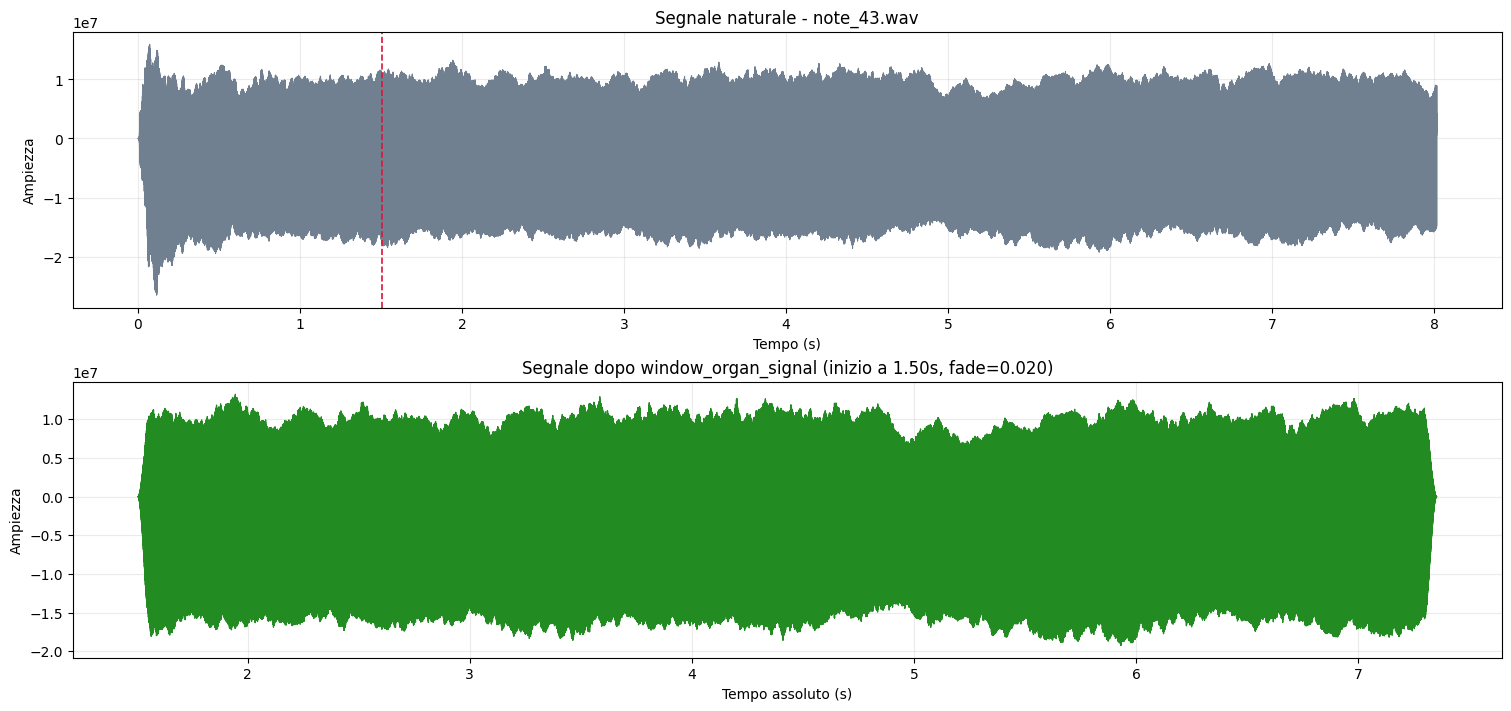

In [6]:
# Esempio visivo: confronto tra segnale naturale e segnale ritagliato/finestrato
sample_file = Path('data/note_43.wav')

samplerate, data = wavfile.read(sample_file)
if data.dtype == np.int16:
    data = data / 32768.0

if len(data.shape) > 1:
    signal_mono = np.mean(data, axis=1)
else:
    signal_mono = data

windowed_signal, start_idx, end_idx, fade_fraction = window_organ_signal(
    signal_mono, samplerate, return_info=True
)

raw_time = np.arange(len(signal_mono)) / samplerate
windowed_time = (start_idx + np.arange(len(windowed_signal))) / samplerate

fig, axes = plt.subplots(2, 1, figsize=(15, 7), constrained_layout=True)

axes[0].plot(raw_time, signal_mono, color='slategray', linewidth=0.8)
axes[0].axvline(start_idx / samplerate, color='crimson', linestyle='--', linewidth=1.2)
axes[0].set_title(f'Segnale naturale - {sample_file.name}')
axes[0].set_xlabel('Tempo (s)')
axes[0].set_ylabel('Ampiezza')
axes[0].grid(True, alpha=0.25)

axes[1].plot(windowed_time, windowed_signal, color='forestgreen', linewidth=0.9)
axes[1].set_title(
    f'Segnale dopo window_organ_signal (inizio a {start_idx / samplerate:.2f}s, fade={fade_fraction:.3f})'
)
axes[1].set_xlabel('Tempo assoluto (s)')
axes[1].set_ylabel('Ampiezza')
axes[1].grid(True, alpha=0.25)

plt.show()

## Trova la frequanza fondamentale anche se manca con MCD

/var/folders/jm/brl1kdcn5mv6s_f18tvp6lsh0000gn/T/ipykernel_4669/1136274059.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(file_path)


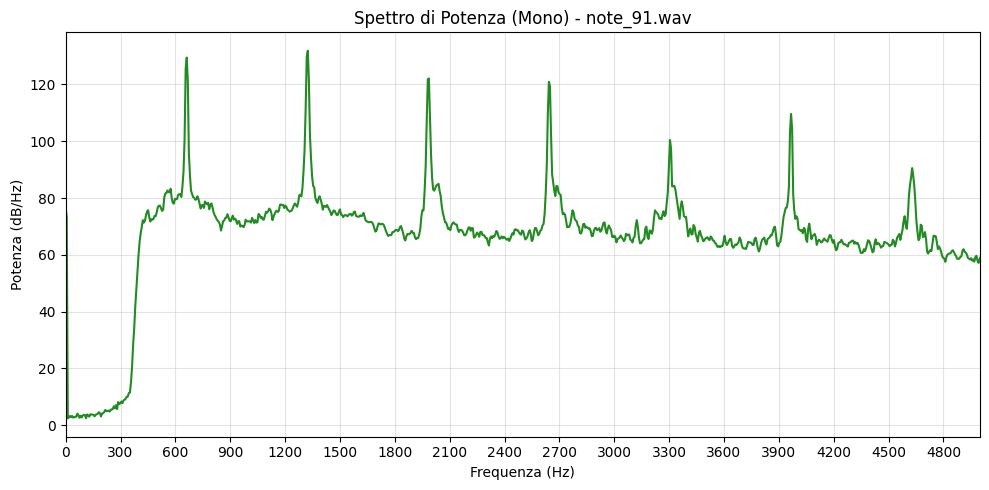

La frequenza fondamentale stimata è: 660.16 Hz


In [7]:
def identifica_f0_media_distanze(freqs, psd, num_picchi=15):
    """
    Identifica la fondamentale calcolando la media delle distanze 
    tra i picchi principali (armoniche). Questo metodo mitiga il problema 
    dell'inarmonicità.
    """
    # 1. Trova i picchi principali (semplice ricerca locale)
    soglia = np.mean(psd) + np.std(psd)
    picchi_idx = []
    for i in range(1, len(psd) - 1):
        if psd[i] > psd[i-1] and psd[i] > psd[i+1] and psd[i] > soglia:
            picchi_idx.append(i)
    
    f_picchi = freqs[picchi_idx[:num_picchi]]
    
    if len(f_picchi) < 2:
        return f_picchi[0] if len(f_picchi) == 1 else 0

    # 2. Calcola le distanze (f_n - f_{n-1}) tra i picchi successivi
    distanze = np.diff(f_picchi)
    
    # 3. La frequenza fondamentale stimata è la media di queste distanze
    f0_stimata = np.mean(distanze)
    
    return f0_stimata

freqs, psd = analizza_nota_welch_mono('data/note_91.wav')
f0 = identifica_f0_media_distanze(freqs, psd)
print(f"La frequenza fondamentale stimata è: {f0:.2f} Hz")


## Analisi di tutte le note: DOVREMMO USARE WELCH COME PRIMA?

In [8]:
def process_organ_notes(folder_path):
    """
    Processa tutte le note dell'organo usando le funzioni di lab3.ipynb:
    - window_organ_signal per ritagliare il segnale
    - calcola_fondamentale per trovare la F0
    - power_spectrum per lo spettro
    - estrai_timbro per il vettore di timbro
    - freq_to_note per convertire in nome nota
    """
    data_dir = Path(folder_path)
    files = sorted(data_dir.glob('note_*.wav'))
    results = {}

    for file_path in files:
        try:
            samplerate, data = wavfile.read(file_path)
            
            # 1. Normalizzazione e gestione Stereo -> Mono
            if data.dtype == np.int16:
                data = data / 32768.0
                
            if len(data.shape) > 1:
                signal = np.mean(data, axis=1)
            else:
                signal = data

            # 2. Ritaglio e windowing (usa la funzione di Acoustics)
            final_signal = window_organ_signal(signal, samplerate)

            # 3. Rimuovi DC (media = 0)
            final_signal = final_signal - np.mean(final_signal)

            # 4. Calcola F0 con algoritmo di voto (lab3)
            f0 = calcola_fondamentale(final_signal, samplerate)
            
            if f0 <= 0:
                print(f"File {file_path.name} scartato: F0 non trovata")
                continue

            # 5. Calcola spettro con finestra gaussiana (lab3)
            freqs, psd = power_spectrum(final_signal, samplerate)

            # 6. Estrai timbro e nota
            timbro = estrai_timbro(freqs, psd, f0)
            nome_nota = freq_to_note(f0)
            
            results[file_path.name] = {
                'freq': freqs,
                'psd': psd,
                'rate': samplerate,
                'f0': f0,
                'nota': nome_nota,
                'timbro': timbro
            }
            
        except Exception as e:
            print(f"Errore nel file {file_path.name}: {e}")
            continue

    return results


# Esegui l'elaborazione
results = process_organ_notes('data/')

print(f'File totali processati: {len(results)}')
print(f'Check psd length: {len(results["note_1.wav"]["psd"])}')
print(f'Sample rate: {results["note_1.wav"]["rate"]}')
print(f'Seconda nota F0: {results["note_2.wav"]["f0"]:.2f} Hz')
print(f'Seconda nota nome: {results["note_2.wav"]["nota"]}')


/var/folders/jm/brl1kdcn5mv6s_f18tvp6lsh0000gn/T/ipykernel_4669/3269854904.py:16: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(file_path)


File totali processati: 280
Check psd length: 32769
Sample rate: 48000
Seconda nota F0: 1481.69 Hz
Seconda nota nome: F#6


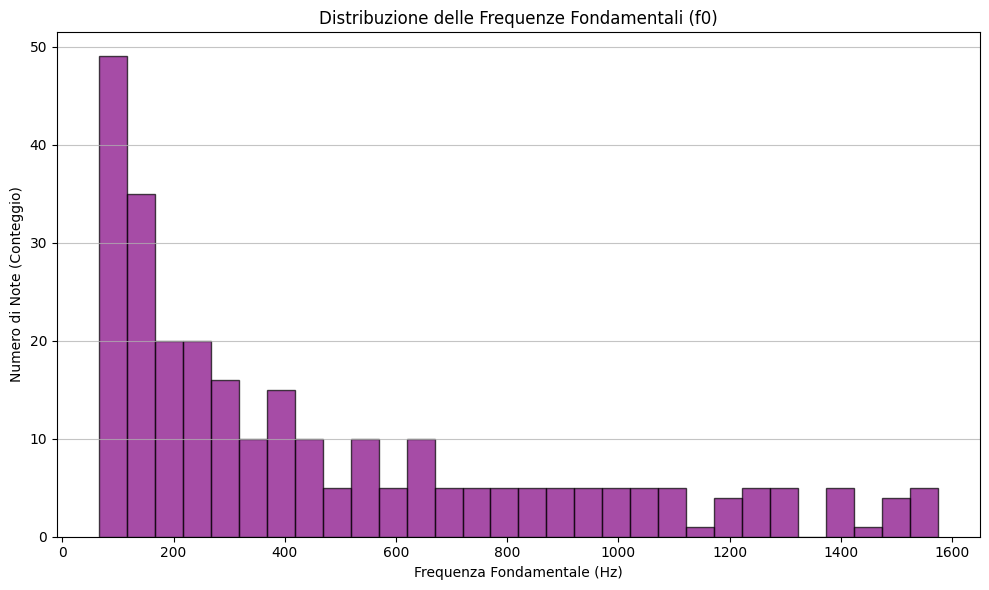

In [9]:
# Estrai tutte le frequenze fondamentali, ignorando eventuali valori a 0 (note non identificate)
f0_values = [data['f0'] for data in results.values() if data['f0'] > 0]

# Crea l'istogramma
plt.figure(figsize=(10, 6))
plt.hist(f0_values, bins=30, color='purple', edgecolor='black', alpha=0.7)

# Personalizza il grafico
plt.title('Distribuzione delle Frequenze Fondamentali (f0)')
plt.xlabel('Frequenza Fondamentale (Hz)')
plt.ylabel('Numero di Note (Conteggio)')
plt.grid(axis='y', alpha=0.75)

# Mostra il grafico
plt.tight_layout()
plt.show()

# sarebbe bello avere delle frequenze di riferimento per le note musicali e vedere se le frequenze fondamentali identificate si allineano con queste frequenze teoriche. 
# Potremmo anche colorare l'istogramma in base alla vicinanza alle frequenze di riferimento per evidenziare quali note sono più rappresentate.

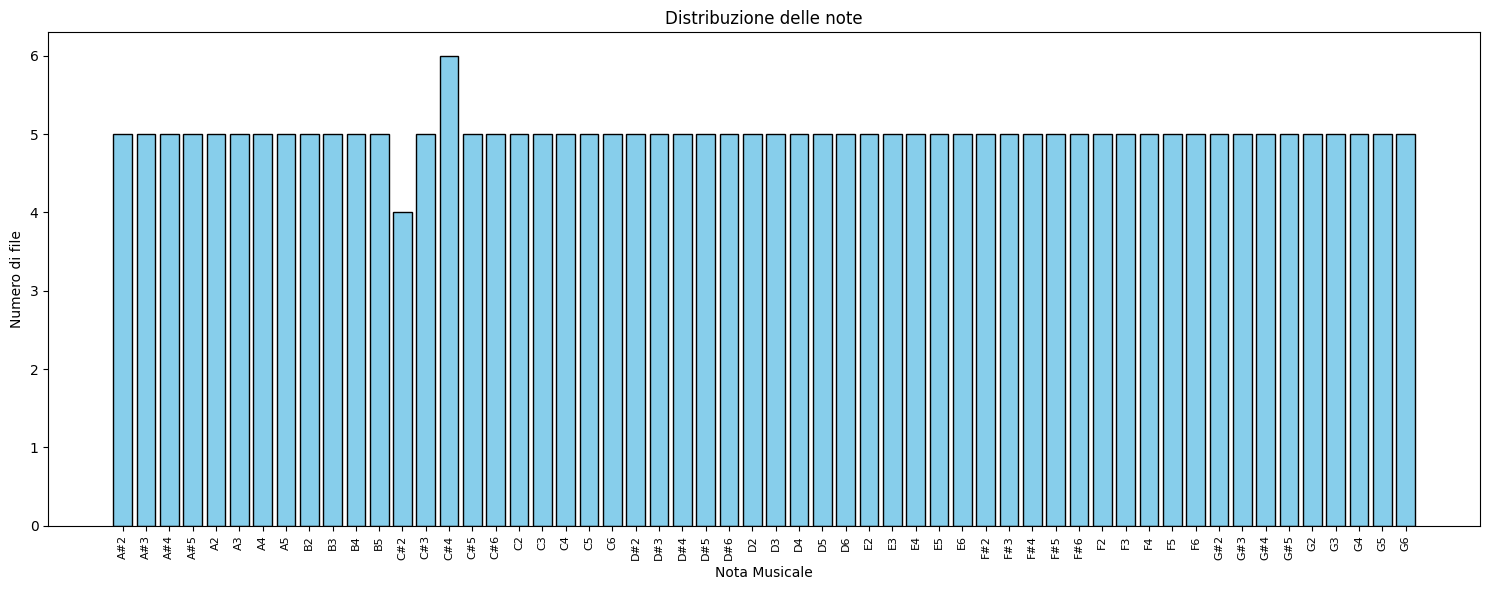

In [10]:
f0_array = np.array(f0_values)  
# 1. Converti in numeri MIDI 
midi_notes = 69 + 12 * np.log2(f0_array / 440) 
# 2. Definisci i nomi delle note 
note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'] 
# 3. Funzione per ottenere il nome con l'ottava (es. 60 -> C4) 
def midi_to_name(n): 
    n = int(round(n)) 
    return f"{note_names[n % 12]}{n // 12 - 1}" 
    
# 4. Prepara i dati per l'istogramma  
labels = [midi_to_name(n) for n in midi_notes] 
unique_labels, counts = np.unique(labels,return_counts=True)  

# 1. Crea una figura molto larga (es. 15 pollici di larghezza, 6 di altezza) 
plt.figure(figsize=(15, 6)) 
# 2. Crea il grafico a barre 
plt.bar(unique_labels, counts, color='skyblue', edgecolor='black') 
# 3. Configura le etichette dell'asse X 
plt.xticks( rotation=90, fontsize=8, ha='center') 
plt.xlabel('Nota Musicale') 
plt.ylabel('Numero di file') 
plt.title('Distribuzione delle note') 
# 4. Ottimizza i margini per non tagliare le etichette in basso
plt.tight_layout() 
plt.show()  

# Estraiamo le ampiezze degli overtoni (armoniche)

In [11]:
def estrai_ampiezze_armoniche(freqs, psd, f0, num_armoniche):
    """Estrae l'ampiezza delle prime N armoniche e le normalizza."""
    armoniche = []
    
    for i in range(1, num_armoniche + 1):
        f_target = f0 * i
        # Trova l'indice dell'array delle frequenze più vicino al multiplo esatto
        #idx = np.argmin(np.abs(freqs - f_target))
        id = np.argmax(psd[(freqs >= f_target - 10) & ( freqs <= f_target + 10)])
        armoniche.append(psd[id])
        
    armoniche = np.array(armoniche)
    
    # NORMALIZZAZIONE FONDAMENTALE: 
    # Dividiamo tutto per l'ampiezza della prima armonica (la f0). 
    # Così confrontiamo il "timbro" (le proporzioni) e non il volume assoluto della registrazione!
    if armoniche[0] > 0:
        armoniche = armoniche / armoniche[0] 
        
    return armoniche

## K-means

In [12]:
# 1. Usa direttamente il campo 'timbro' già calcolato da process_organ_notes
#    Il timbro contiene le prime 5 armoniche normalizzate
X = []
nomi_file = []

for file_name, data in results.items():
    if data['f0'] > 0 and 'timbro' in data:
        # Usa il vettore timbro (già normalizzato)
        X.append(data['timbro'][1:])  # Ignora la prima colonna (= 1.0)
        nomi_file.append(file_name)

X = np.array(X)

# 2. Applichiamo il K-Means
# Scegli il numero di cluster (K). Se sai di avere 3 registri diversi nel dataset, metti 3.
NUMERO_REGISTRI = 5
kmeans = KMeans(n_clusters=NUMERO_REGISTRI, random_state=42)

# Addestriamo il modello e otteniamo le etichette (i gruppi assegnati)
labels = kmeans.fit_predict(X)

# 3. Stampiamo i risultati
print("\n--- RISULTATI CLUSTERING ---")
for name, label in zip(nomi_file, labels):
    print(f"File: {name} -> Assegnato al Cluster (Registro): {label}")


--- RISULTATI CLUSTERING ---
File: note_1.wav -> Assegnato al Cluster (Registro): 0
File: note_10.wav -> Assegnato al Cluster (Registro): 0
File: note_100.wav -> Assegnato al Cluster (Registro): 2
File: note_101.wav -> Assegnato al Cluster (Registro): 1
File: note_102.wav -> Assegnato al Cluster (Registro): 4
File: note_103.wav -> Assegnato al Cluster (Registro): 1
File: note_104.wav -> Assegnato al Cluster (Registro): 1
File: note_105.wav -> Assegnato al Cluster (Registro): 1
File: note_106.wav -> Assegnato al Cluster (Registro): 1
File: note_107.wav -> Assegnato al Cluster (Registro): 1
File: note_108.wav -> Assegnato al Cluster (Registro): 1
File: note_109.wav -> Assegnato al Cluster (Registro): 3
File: note_11.wav -> Assegnato al Cluster (Registro): 1
File: note_110.wav -> Assegnato al Cluster (Registro): 0
File: note_111.wav -> Assegnato al Cluster (Registro): 1
File: note_112.wav -> Assegnato al Cluster (Registro): 1
File: note_113.wav -> Assegnato al Cluster (Registro): 3
File:

In [13]:
results_df = pd.DataFrame({'File': nomi_file, 'Cluster': labels})
for i in range(NUMERO_REGISTRI):
    print(f"\nNote nel Cluster {i} (Probabile Registro {i}):")
    print(results_df[results_df['Cluster'] == i]['File'].values)


Note nel Cluster 0 (Probabile Registro 0):
['note_1.wav' 'note_10.wav' 'note_110.wav' 'note_114.wav' 'note_120.wav'
 'note_128.wav' 'note_129.wav' 'note_134.wav' 'note_140.wav'
 'note_142.wav' 'note_158.wav' 'note_170.wav' 'note_180.wav'
 'note_182.wav' 'note_185.wav' 'note_187.wav' 'note_192.wav'
 'note_193.wav' 'note_210.wav' 'note_212.wav' 'note_221.wav'
 'note_222.wav' 'note_224.wav' 'note_229.wav' 'note_239.wav'
 'note_243.wav' 'note_244.wav' 'note_247.wav' 'note_260.wav'
 'note_273.wav' 'note_28.wav' 'note_31.wav' 'note_38.wav' 'note_40.wav'
 'note_41.wav' 'note_43.wav' 'note_46.wav' 'note_47.wav' 'note_50.wav'
 'note_52.wav' 'note_55.wav' 'note_65.wav' 'note_72.wav' 'note_73.wav'
 'note_74.wav' 'note_80.wav' 'note_81.wav' 'note_9.wav' 'note_91.wav'
 'note_92.wav' 'note_95.wav' 'note_97.wav' 'note_98.wav']

Note nel Cluster 1 (Probabile Registro 1):
['note_101.wav' 'note_103.wav' 'note_104.wav' 'note_105.wav'
 'note_106.wav' 'note_107.wav' 'note_108.wav' 'note_11.wav' 'note_111.

## K-means con PCD

In [14]:
# Supponiamo che 'X' sia la tua matrice con 5 armoniche (f0, f1, f2, f3, f4)
# X = np.array(...) 

# 1. Standardizzazione (Fondamentale per la PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Applicazione della PCA per ridurre a 2 dimensioni
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Esecuzione del K-Means sui dati "schiacciati" dalla PCA
N_CLUSTERS_PCA = 5
kmeans = KMeans(n_clusters=N_CLUSTERS_PCA, random_state=42)
labels = kmeans.fit_predict(X_pca) # o su X_scaled, il risultato visivo sarà coerente

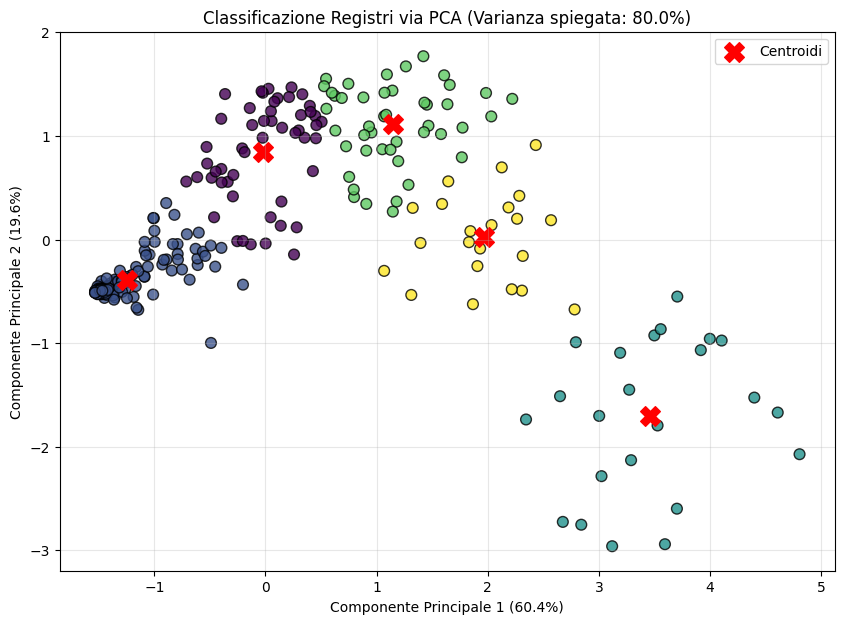

In [15]:
plt.figure(figsize=(10, 7))

# Plot dei punti
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=60, alpha=0.8, edgecolors='k')

# Plot dei centroidi
centroids_pca = kmeans.cluster_centers_
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='red', label='Centroidi')

# Calcolo della varianza spiegata (per capire quanto è accurato il riassunto)
var_exp = pca.explained_variance_ratio_
plt.title(f"Classificazione Registri via PCA (Varianza spiegata: {sum(var_exp)*100:.1f}%)")
plt.xlabel(f"Componente Principale 1 ({var_exp[0]*100:.1f}%)")
plt.ylabel(f"Componente Principale 2 ({var_exp[1]*100:.1f}%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
results_df = pd.DataFrame({'File': nomi_file, 'Cluster': labels})
for i in range(N_CLUSTERS_PCA):
    print(f"\nNote nel Cluster {i} (Probabile Registro {i}):")
    print(results_df[results_df['Cluster'] == i]['File'].values)


Note nel Cluster 0 (Probabile Registro 0):
['note_1.wav' 'note_110.wav' 'note_120.wav' 'note_128.wav' 'note_129.wav'
 'note_13.wav' 'note_134.wav' 'note_140.wav' 'note_142.wav' 'note_166.wav'
 'note_170.wav' 'note_174.wav' 'note_180.wav' 'note_182.wav'
 'note_187.wav' 'note_190.wav' 'note_192.wav' 'note_193.wav'
 'note_196.wav' 'note_210.wav' 'note_212.wav' 'note_221.wav'
 'note_222.wav' 'note_224.wav' 'note_229.wav' 'note_239.wav'
 'note_244.wav' 'note_273.wav' 'note_28.wav' 'note_31.wav' 'note_33.wav'
 'note_38.wav' 'note_41.wav' 'note_43.wav' 'note_46.wav' 'note_47.wav'
 'note_50.wav' 'note_52.wav' 'note_55.wav' 'note_65.wav' 'note_72.wav'
 'note_73.wav' 'note_74.wav' 'note_80.wav' 'note_81.wav' 'note_9.wav'
 'note_91.wav' 'note_92.wav' 'note_93.wav' 'note_97.wav' 'note_98.wav']

Note nel Cluster 1 (Probabile Registro 1):
['note_101.wav' 'note_103.wav' 'note_104.wav' 'note_105.wav'
 'note_106.wav' 'note_107.wav' 'note_108.wav' 'note_11.wav' 'note_111.wav'
 'note_112.wav' 'note_115.